Libraries loaded successfully.
OpenAI client initialised.
Male   payloads : 20
Female payloads : 20

=== Sample Payload (Male Case 0) ===
{
  "case_id": 0,
  "gender": "male",
  "age": 66,
  "original_prob": 0.9218,
  "cf_prob": 0.203,
  "prob_reduction": 0.7188,
  "changed_features": [
    {
      "feature": "HE_wc",
      "original_value": 100.4,
      "cf_value": 68.0,
      "delta": -32.4
    }
  ],
  "static_features": {
    "HE_BMI": 29.932938001351257,
    "HE_wc": 100.4,
    "age": 66.0,
    "BS3_1": "1",
    "BD1_11": "6",
    "pa_aerobic": "0"
  }
}
Variable label and category mapping ready.
  Variables mapped  : 30
  Cat. vars mapped  : 19
=== Test Run: Male Case 0 ===

--- User Prompt Preview ---
=== INPUT DATA FOR CONSULTATION GUIDE GENERATION ===

[Subject Profile]
- Gender : Male
- Age    : 66 years

[Current Risk Assessment]
- Diabetes risk probability (XGBoost model): 92.2%
- Risk category: High-risk non-diabetic group
  (statistical association-based; not a clinical d

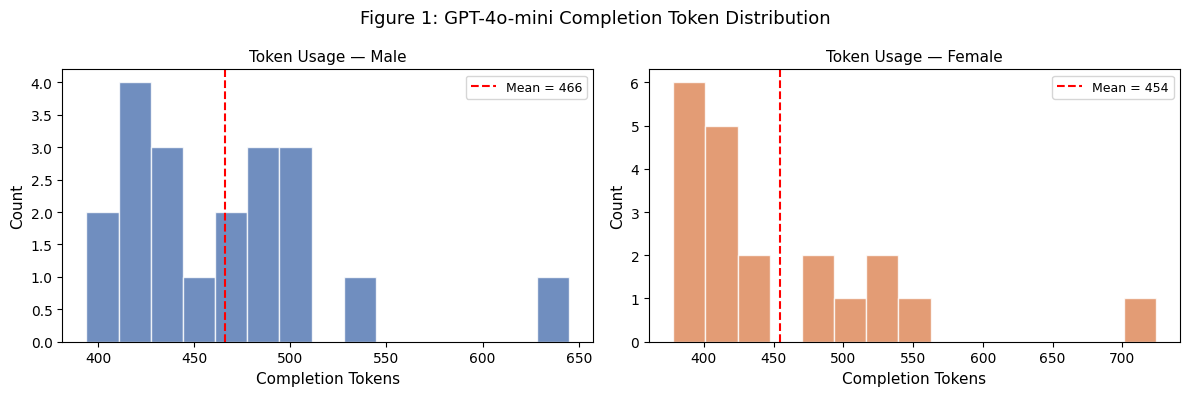

Saved: outputs/llm_outputs/fig1_token_distribution.png

Representative Consultation Guide — Male Case 0
  Age: 66 | Original risk: 92.2% | CF risk: 20.3% | Reduction: 71.9%

## 1. Summary
The current profile indicates a 66-year-old male with a high-risk probability of 92.2% for diabetes, categorized as a high-risk non-diabetic group based on statistical associations. A significant potential risk reduction of 71.9 percentage points is observed in a hypothetical scenario where certain lifestyle changes are made.

## 2. Counterfactual Scenario Interpretation
In this hypothetical scenario, the diabetes risk probability decreases from 92.2% to 20.3%. This change is based on statistical associations rather than direct causation, meaning that while these lifestyle modifications may be linked to lower risk, they do not guarantee a specific outcome. It highlights the potential benefits of adopting healthier habits.

## 3. Hypothetical Lifestyle Modification Scenarios

- **Waist Circumference**


In [5]:
# ============================================================
# 10_llm_prompt_engineering.ipynb
# LLM-Based Natural Language Consultation Guide Generation
#
# Paper: A Methodology for Interpretable Health Risk Management:
#        Integrating Counterfactual Explanations and
#        On-Premise Medical LLMs in the Insurance Industry
#
# Model  : GPT-4o-mini (OpenAI API)
# Input  : DiCE counterfactual payloads (notebooks 07 & 08)
# Output : Structured natural language consultation guides
#
# Note on On-Premise Deployment:
#   This notebook uses GPT-4o-mini via API for proof-of-concept
#   validation. In real-world insurance/healthcare deployment,
#   an on-premise solution (e.g., Meerkat-8B) is strongly
#   recommended due to the sensitivity of personal medical data
#   and regulatory requirements (GDPR, PIPA).
#   See Section 6 (Future Work) of the paper for details.
# ============================================================


# ─────────────────────────────────────────────
# Cell 1 | Library Imports
# ─────────────────────────────────────────────
import os
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from openai import OpenAI
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# Load API key from .env file
# Create a .env file in the project root:
#   OPENAI_API_KEY=sk-xxxxxxxxxxxxxxxxxxxxxxxx
load_dotenv()
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

os.makedirs('outputs/llm_outputs', exist_ok=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("Libraries loaded successfully.")
print(f"OpenAI client initialised.")


# ─────────────────────────────────────────────
# Cell 2 | Load DiCE Payloads
# ─────────────────────────────────────────────
with open('outputs/dice_male/llm_input_male.json',
          encoding='utf-8') as f:
    payloads_male = json.load(f)

with open('outputs/dice_female/llm_input_female.json',
          encoding='utf-8') as f:
    payloads_female = json.load(f)

print(f"Male   payloads : {len(payloads_male)}")
print(f"Female payloads : {len(payloads_female)}")
print("\n=== Sample Payload (Male Case 0) ===")
print(json.dumps(payloads_male[0], indent=2, default=str))


# ─────────────────────────────────────────────
# Cell 3 | Variable Label & Category Mapping
#          (Code → Human-readable English)
#          Source: KNHANES codebook (translated)
# ─────────────────────────────────────────────

# ── Variable name → English label ────────────
VAR_LABELS = {
    # Continuous
    'HE_BMI'    : 'Body Mass Index (BMI, kg/m²)',
    'HE_wc'     : 'Waist Circumference (cm)',
    'HE_wt'     : 'Body Weight (kg)',
    'N_SUGAR'   : 'Daily Sugar Intake (g)',
    'N_CHO'     : 'Daily Carbohydrate Intake (g)',
    'N_EN'      : 'Daily Energy Intake (kcal)',
    'age'       : 'Age (years)',
    # Categorical
    'HE_obe'    : 'Obesity Status (19+)',
    'BO1_1'     : 'Weight Change in Past Year (adults)',
    'BO1_2'     : 'Weight Loss Amount in Past Year (adults)',
    'BO1_3'     : 'Weight Gain Amount in Past Year (adults)',
    'BD1_11'    : 'Alcohol Drinking Frequency (aged 12+)',
    'BD2_1'     : 'Alcohol Amount per Drinking Occasion (aged 12+)',
    'BS3_1'     : 'Current Cigarette Smoking Status (adults)',
    'BE3_71'    : 'High-Intensity Physical Activity at Work',
    'BE3_75'    : 'High-Intensity Physical Activity during Leisure',
    'BE3_81'    : 'Moderate-Intensity Physical Activity at Work',
    'BE3_91'    : 'Physical Activity for Transportation',
    'pa_aerobic': 'Aerobic Physical Activity Practice Rate',
    'L_BR_FQ'   : 'Breakfast Frequency per Week (past year)',
    'BP1'       : 'Perceived Stress Level (usual)',
    'mh_stress' : 'Stress Recognition Rate',
    'incm'      : 'Individual Income Quartile',
    'ho_incm'   : 'Household Income Quartile',
    'edu'       : 'Education Level (reclassified)',
    'BH1'       : 'Health Checkup Utilisation (adults)',
    # Target / Key
    'HE_DM_HbA1c': 'Diabetes Status incl. HbA1c (19+)',
    'ID'         : 'Participant ID',
    'year'       : 'Survey Year',
    'sex'        : 'Sex',
}

# ── Categorical value → English label ────────
CAT_LABELS = {
    'HE_obe': {
        1: 'Underweight',
        2: 'Normal weight',
        3: 'Overweight (pre-obese)',
        4: 'Obesity class I',
        5: 'Obesity class II',
        6: 'Obesity class III',
    },
    'BO1_1': {
        1: 'No change',
        2: 'Weight loss',
        3: 'Weight gain',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
    'BO1_2': {
        1: '3 kg – <6 kg',
        2: '6 kg – <10 kg',
        3: '10 kg or more',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
    'BO1_3': {
        1: '3 kg – <6 kg',
        2: '6 kg – <10 kg',
        3: '10 kg or more',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
    'BD1_11': {
        1: 'Not at all in the past year',
        2: 'Less than once a month',
        3: 'About once a month',
        4: '2–4 times a month',
        5: '2–3 times a week',
        6: '4 or more times a week',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
    'BD2_1': {
        1: '1–2 glasses',
        2: '3–4 glasses',
        3: '5–6 glasses',
        4: '7–9 glasses',
        5: '10 glasses or more',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
    'BS3_1': {
        1: 'Currently smoking daily',
        2: 'Currently smoking occasionally',
        3: 'Former smoker (not currently smoking)',
        8: 'Not applicable (never smoked)',
        9: 'Unknown / No response',
    },
    'BE3_71': {
        1: 'Yes',
        2: 'No',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
    'BE3_75': {
        1: 'Yes',
        2: 'No',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
    'BE3_81': {
        1: 'Yes',
        2: 'No',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
    'BE3_91': {
        1: 'Yes',
        2: 'No',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
    'pa_aerobic': {
        0: 'Not practising moderate- or high-intensity physical activity',
        1: 'Practising moderate- or high-intensity physical activity',
    },
    'L_BR_FQ': {
        1: '5–7 days per week',
        2: '3–4 days per week',
        3: '1–2 days per week',
        4: 'Rarely or never (0 days per week)',
        9: 'Unknown / No response',
    },
    'BP1': {
        1: 'Extremely stressed',
        2: 'Tend to feel a lot of stress',
        3: 'Tend to feel a little stress',
        4: 'Rarely feel stress',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
    'mh_stress': {
        0: 'Low stress',
        1: 'High stress',
    },
    'incm': {
        1: 'Low (Q1)',
        2: 'Low-middle (Q2)',
        3: 'High-middle (Q3)',
        4: 'High (Q4)',
    },
    'ho_incm': {
        1: 'Low (Q1)',
        2: 'Low-middle (Q2)',
        3: 'High-middle (Q3)',
        4: 'High (Q4)',
    },
    'edu': {
        1: 'Elementary school or below',
        2: 'Middle school',
        3: 'High school',
        4: 'College / University or above',
    },
    'BH1': {
        1: 'Yes (received health checkup)',
        2: 'No (did not receive health checkup)',
        8: 'Not applicable',
        9: 'Unknown / No response',
    },
}

def label(code):
    """Return English variable label for a given variable code."""
    return VAR_LABELS.get(code, code)

def cat_label(code, value):
    """
    Return English category label for a given variable code and value.
    Falls back to raw value if mapping not found.
    """
    try:
        val_int = int(float(value))
        return CAT_LABELS.get(code, {}).get(val_int, str(value))
    except (ValueError, TypeError):
        return str(value)

print("Variable label and category mapping ready.")
print(f"  Variables mapped  : {len(VAR_LABELS)}")
print(f"  Cat. vars mapped  : {len(CAT_LABELS)}")


# ─────────────────────────────────────────────
# Cell 4 | System Prompt Definition
# ─────────────────────────────────────────────
SYSTEM_PROMPT = """You are a health risk communication specialist \
working for an insurance company's internal risk analysis team.

Your role is to convert statistical counterfactual analysis results \
into clear, empathetic, and structured health consultation guides \
for internal review — NOT for direct patient communication.

STRICT RULES:
1. All recommendations are based on STATISTICAL ASSOCIATIONS only, \
not causal relationships. Always make this explicit.
2. Never use the word "will" regarding health outcomes. \
Use "may be associated with", "statistically linked to", \
"observed in similar profiles", etc.
3. Always include a disclaimer that this is not medical advice \
and professional consultation is required.
4. Be specific with numbers (e.g., "reducing waist circumference \
from 97cm to 83cm") rather than vague (e.g., "lose weight").
5. Structure the output in clearly labelled sections.
6. Keep a professional but empathetic tone.
7. Output in English."""


# ─────────────────────────────────────────────
# Cell 5 | Prompt Builder Function
# ─────────────────────────────────────────────
def build_user_prompt(payload):
    """
    Converts a DiCE payload dict into a structured user prompt
    for GPT-4o-mini.
    """
    gender       = payload['gender'].capitalize()
    age          = payload['age']
    orig_prob    = payload['original_prob']
    cf_prob      = payload['cf_prob']
    reduction    = payload['prob_reduction']
    changed      = payload['changed_features']
    static       = payload.get('static_features', {})

    # Format changed features
    changed_lines = []
    for item in changed:
        feat  = label(item['feature'])
        orig  = item['original_value']
        cf    = item['cf_value']
        delta = item.get('delta')
        if delta is not None:
            direction = 'decrease' if delta < 0 else 'increase'
            changed_lines.append(
                f"  - {feat}: {orig} → {cf} "
                f"({direction} of {abs(delta):.2f})"
            )
        else:
            orig_str = cat_label(item['feature'], orig)
            cf_str   = cat_label(item['feature'], cf)
            changed_lines.append(
                f"  - {feat}: '{orig_str}' → '{cf_str}'"
            )

    # Format static profile
    static_lines = []
    for k, v in static.items():
        static_lines.append(f"  - {label(k)}: {v}")

    prompt = f"""
=== INPUT DATA FOR CONSULTATION GUIDE GENERATION ===

[Subject Profile]
- Gender : {gender}
- Age    : {age} years

[Current Risk Assessment]
- Diabetes risk probability (XGBoost model): {orig_prob:.1%}
- Risk category: High-risk non-diabetic group
  (statistical association-based; not a clinical diagnosis)

[Counterfactual Scenario]
- Hypothetical risk probability: {cf_prob:.1%}
- Risk reduction (association-based): {reduction:.1%} points

[Key Feature Changes in Counterfactual Scenario]
{chr(10).join(changed_lines)}

[Additional Profile Information]
{chr(10).join(static_lines) if static_lines else '  (Not available)'}

=== TASK ===
Generate a structured health risk consultation guide based on the \
above counterfactual analysis. Follow this exact output structure:

## 1. Summary
(2–3 sentences: current profile, association-based risk level, \
key takeaway)

## 2. Counterfactual Scenario Interpretation
(Explain what the hypothetical scenario means in plain language. \
Emphasise statistical association, not causation.)

## 3. Hypothetical Lifestyle Modification Scenarios
(For each changed feature, provide:
 - Current value and counterfactual target
 - Evidence-based context (brief, 1–2 sentences)
 - Practical examples of how this change might be approached)

## 4. Important Limitations
(Cross-sectional data, reverse causality, association ≠ causation,
 individual variation)

## 5. Disclaimer
(This is for internal risk analysis only. Not medical advice. \
Professional consultation required.)
"""
    return prompt.strip()


# ─────────────────────────────────────────────
# Cell 6 | GPT-4o-mini API Call Function
# ─────────────────────────────────────────────
def call_gpt(user_prompt,
             model       = 'gpt-4o-mini',
             temperature = 0.3,
             max_tokens  = 1200,
             retry       = 3,
             wait        = 5):
    """
    Calls GPT-4o-mini with retry logic.
    temperature=0.3 for consistent, reproducible outputs.
    """
    for attempt in range(retry):
        try:
            response = client.chat.completions.create(
                model       = model,
                temperature = temperature,
                max_tokens  = max_tokens,
                messages    = [
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': user_prompt},
                ],
            )
            return {
                'content'       : response.choices[0].message.content,
                'model'         : response.model,
                'prompt_tokens' : response.usage.prompt_tokens,
                'completion_tokens': response.usage.completion_tokens,
                'total_tokens'  : response.usage.total_tokens,
            }
        except Exception as e:
            print(f"  [Attempt {attempt+1}/{retry}] API error: {e}")
            if attempt < retry - 1:
                time.sleep(wait)
    return None


# ─────────────────────────────────────────────
# Cell 7 | Single Case Test Run
#          (Verify prompt & output before batch)
# ─────────────────────────────────────────────
print("=== Test Run: Male Case 0 ===\n")

test_payload = payloads_male[0]
test_prompt  = build_user_prompt(test_payload)

print("--- User Prompt Preview ---")
print(test_prompt[:800], "...[truncated]\n")

test_result = call_gpt(test_prompt)

if test_result:
    print("--- GPT-4o-mini Output ---")
    print(test_result['content'])
    print(f"\n[Token Usage] "
          f"Prompt: {test_result['prompt_tokens']} | "
          f"Completion: {test_result['completion_tokens']} | "
          f"Total: {test_result['total_tokens']}")
else:
    print("[Error] API call failed.")


# ─────────────────────────────────────────────
# Cell 8 | Batch Generation — Male
# ─────────────────────────────────────────────
BATCH_MALE_N   = len(payloads_male)
SAVE_PATH_MALE = 'outputs/llm_outputs/llm_outputs_male.csv'

if os.path.exists(SAVE_PATH_MALE):
    df_outputs_male = pd.read_csv(SAVE_PATH_MALE)
    total_tokens_m  = int(df_outputs_male['total_tokens'].sum())
    print(f"[Skip] Male outputs already exist → loaded {len(df_outputs_male)} cases")
else:
    print(f"Batch generation — Male ({BATCH_MALE_N} cases)...")
    results_male   = []
    total_tokens_m = 0

    for i, payload in enumerate(payloads_male[:BATCH_MALE_N]):
        prompt = build_user_prompt(payload)
        result = call_gpt(prompt)

        if result:
            record = {
                'case_id'           : payload['case_id'],
                'gender'            : payload['gender'],
                'age'               : payload['age'],
                'original_prob'     : payload['original_prob'],
                'cf_prob'           : payload['cf_prob'],
                'prob_reduction'    : payload['prob_reduction'],
                'n_changed_features': len(payload['changed_features']),
                'llm_output'        : result['content'],
                'model'             : result['model'],
                'prompt_tokens'     : result['prompt_tokens'],
                'completion_tokens' : result['completion_tokens'],
                'total_tokens'      : result['total_tokens'],
            }
            results_male.append(record)
            total_tokens_m += result['total_tokens']

            if (i + 1) % 5 == 0:
                print(f"  [{i+1}/{BATCH_MALE_N}] "
                      f"case_id={payload['case_id']} | "
                      f"tokens={result['total_tokens']}")
            time.sleep(1)
        else:
            print(f"  [Warning] Case {payload['case_id']} failed.")

    df_outputs_male = pd.DataFrame(results_male)
    df_outputs_male.to_csv(SAVE_PATH_MALE, index=False, encoding='utf-8')
    print(f"\nMale outputs saved: {len(df_outputs_male)} cases")

print(f"Total tokens used : {total_tokens_m:,}")


# ─────────────────────────────────────────────
# Cell 9 | Batch Generation — Female
# ─────────────────────────────────────────────
BATCH_FEMALE_N   = len(payloads_female)
SAVE_PATH_FEMALE = 'outputs/llm_outputs/llm_outputs_female.csv'

if os.path.exists(SAVE_PATH_FEMALE):
    df_outputs_female = pd.read_csv(SAVE_PATH_FEMALE)
    total_tokens_f    = int(df_outputs_female['total_tokens'].sum())
    print(f"[Skip] Female outputs already exist → loaded {len(df_outputs_female)} cases")
else:
    print(f"Batch generation — Female ({BATCH_FEMALE_N} cases)...")
    results_female = []
    total_tokens_f = 0

    for i, payload in enumerate(payloads_female[:BATCH_FEMALE_N]):
        prompt = build_user_prompt(payload)
        result = call_gpt(prompt)

        if result:
            record = {
                'case_id'           : payload['case_id'],
                'gender'            : payload['gender'],
                'age'               : payload['age'],
                'original_prob'     : payload['original_prob'],
                'cf_prob'           : payload['cf_prob'],
                'prob_reduction'    : payload['prob_reduction'],
                'n_changed_features': len(payload['changed_features']),
                'llm_output'        : result['content'],
                'model'             : result['model'],
                'prompt_tokens'     : result['prompt_tokens'],
                'completion_tokens' : result['completion_tokens'],
                'total_tokens'      : result['total_tokens'],
            }
            results_female.append(record)
            total_tokens_f += result['total_tokens']

            if (i + 1) % 5 == 0:
                print(f"  [{i+1}/{BATCH_FEMALE_N}] "
                      f"case_id={payload['case_id']} | "
                      f"tokens={result['total_tokens']}")
            time.sleep(1)
        else:
            print(f"  [Warning] Case {payload['case_id']} failed.")

    df_outputs_female = pd.DataFrame(results_female)
    df_outputs_female.to_csv(SAVE_PATH_FEMALE, index=False, encoding='utf-8')
    print(f"\nFemale outputs saved: {len(df_outputs_female)} cases")

print(f"Total tokens used : {total_tokens_f:,}")


# ─────────────────────────────────────────────
# Cell 10 | Output Quality Inspection
#           Section Completeness Check
# ─────────────────────────────────────────────
REQUIRED_SECTIONS = [
    '## 1. Summary',
    '## 2. Counterfactual Scenario Interpretation',
    '## 3. Hypothetical Lifestyle Modification Scenarios',
    '## 4. Important Limitations',
    '## 5. Disclaimer',
]

def check_sections(text):
    return {
        sec.replace('## ', ''): sec in text
        for sec in REQUIRED_SECTIONS
    }

print("=== Section Completeness Check ===\n")

for label_g, df_out in [('Male', df_outputs_male),
                          ('Female', df_outputs_female)]:
    records = []
    for _, row in df_out.iterrows():
        checks = check_sections(row['llm_output'])
        checks['case_id'] = row['case_id']
        records.append(checks)
    df_check = pd.DataFrame(records).set_index('case_id')

    completeness = df_check.mean() * 100
    print(f"[{label_g}] Section inclusion rate (%):")
    for sec, pct in completeness.items():
        status = '✓' if pct == 100 else f'⚠ {pct:.0f}%'
        print(f"  {status}  {sec}")
    print()


# ─────────────────────────────────────────────
# Cell 11 | Output Length Statistics
# ─────────────────────────────────────────────
df_all_outputs = pd.concat(
    [df_outputs_male, df_outputs_female],
    ignore_index=True
)
df_all_outputs['output_chars'] = df_all_outputs['llm_output'].str.len()
df_all_outputs['output_words'] = df_all_outputs['llm_output'].str.split().str.len()

print("=== Output Length Statistics ===")
for g in ['male', 'female']:
    sub = df_all_outputs[df_all_outputs['gender'] == g]
    print(f"\n  [{g.capitalize()}]")
    print(f"    Avg chars  : {sub['output_chars'].mean():.0f} "
          f"± {sub['output_chars'].std():.0f}")
    print(f"    Avg words  : {sub['output_words'].mean():.0f} "
          f"± {sub['output_words'].std():.0f}")
    print(f"    Avg tokens : {sub['completion_tokens'].mean():.0f} "
          f"± {sub['completion_tokens'].std():.0f}")

print(f"\n  [Total API cost estimate]")
total_tokens = df_all_outputs['total_tokens'].sum()
# GPT-4o-mini pricing: ~$0.15/1M input + $0.60/1M output tokens (2024)
est_cost = (df_all_outputs['prompt_tokens'].sum() * 0.15 +
            df_all_outputs['completion_tokens'].sum() * 0.60) / 1_000_000
print(f"    Total tokens : {total_tokens:,}")
print(f"    Est. cost    : ${est_cost:.4f} USD")


# ─────────────────────────────────────────────
# Cell 12 | Figure 1 — Token Usage Distribution
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (g, color) in zip(axes, [('male','#4C72B0'), ('female','#DD8452')]):
    sub = df_all_outputs[df_all_outputs['gender'] == g]
    ax.hist(sub['completion_tokens'], bins=15,
            color=color, alpha=0.8, edgecolor='white')
    ax.axvline(sub['completion_tokens'].mean(), color='red',
               linestyle='--',
               label=f"Mean = {sub['completion_tokens'].mean():.0f}")
    ax.set_xlabel('Completion Tokens', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'Token Usage — {g.capitalize()}', fontsize=11)
    ax.legend(fontsize=9)

fig.suptitle('Figure 1: GPT-4o-mini Completion Token Distribution',
             fontsize=13)
plt.tight_layout()
plt.savefig('outputs/llm_outputs/fig1_token_distribution.png',
            bbox_inches='tight')
plt.show()
print("Saved: outputs/llm_outputs/fig1_token_distribution.png")


# ─────────────────────────────────────────────
# Cell 13 | Representative Output Display
#           Male & Female Case 0
# ─────────────────────────────────────────────
for g, df_out in [('Male', df_outputs_male), ('Female', df_outputs_female)]:
    row = df_out[df_out['case_id'] == 0].iloc[0]
    print(f"\n{'='*65}")
    print(f"Representative Consultation Guide — {g} Case 0")
    print(f"  Age: {row['age']} | "
          f"Original risk: {row['original_prob']:.1%} | "
          f"CF risk: {row['cf_prob']:.1%} | "
          f"Reduction: {row['prob_reduction']:.1%}")
    print(f"{'='*65}\n")
    print(row['llm_output'])


# ─────────────────────────────────────────────
# Cell 14 | Export Combined JSON
#           (Input for notebook 11 — LLM Judge)
# ─────────────────────────────────────────────
combined_for_judge = []

for _, row in df_all_outputs.iterrows():
    # Find original payload
    payloads_src = (payloads_male
                    if row['gender'] == 'male'
                    else payloads_female)
    payload = next(
        (p for p in payloads_src if p['case_id'] == row['case_id']),
        {}
    )
    combined_for_judge.append({
        'case_id'           : int(row['case_id']),
        'gender'            : row['gender'],
        'age'               : int(row['age']),
        'original_prob'     : float(row['original_prob']),
        'cf_prob'           : float(row['cf_prob']),
        'prob_reduction'    : float(row['prob_reduction']),
        'n_changed_features': int(row['n_changed_features']),
        'changed_features'  : payload.get('changed_features', []),
        'llm_output'        : row['llm_output'],
        'completion_tokens' : int(row['completion_tokens']),
    })

with open('outputs/llm_outputs/llm_outputs_for_judge.json', 'w',
          encoding='utf-8') as f:
    json.dump(combined_for_judge, f, indent=2, ensure_ascii=False)

print(f"Combined judge input saved: {len(combined_for_judge)} cases")
print("Saved: outputs/llm_outputs/llm_outputs_for_judge.json")


# ─────────────────────────────────────────────
# Cell 15 | On-Premise Deployment Note
#           (Paper Section 6 reference)
# ─────────────────────────────────────────────
onpremise_note = """
=================================================================
NOTE ON ON-PREMISE DEPLOYMENT (Paper Section 6 — Future Work)
=================================================================

This notebook uses GPT-4o-mini via the OpenAI API for
proof-of-concept validation. In production deployment within
insurance or healthcare organisations, the following
on-premise approach is strongly recommended:

  Reasons:
  ├─ Personal medical data sensitivity (PIPA, GDPR compliance)
  ├─ No data transmission to external servers
  ├─ Full customisation of model behaviour
  └─ Auditability for regulatory purposes

  Recommended On-Premise Stack:
  ├─ LLM       : Meerkat-8B (medical-specialised, Kim et al. 2025)
  ├─ Inference : vLLM (OpenAI-compatible REST API)
  ├─ Hardware  : NVIDIA RTX 4060Ti 16GB+ / A100 recommended
  ├─ Quant.    : 4-bit GPTQ for memory efficiency
  └─ Interface : REST API (drop-in replacement for OpenAI client)

  Migration Path:
    # Replace Cell 1 client initialisation with:
    client = OpenAI(
        base_url = "http://localhost:8000/v1",
        api_key  = "EMPTY",   # vLLM does not require a key
    )
    # Replace model name:
    model = "meerkat-8b"      # instead of "gpt-4o-mini"
    # All other code remains identical.

=================================================================
"""
print(onpremise_note)


# ─────────────────────────────────────────────
# Cell 16 | Summary Report
# ─────────────────────────────────────────────
print("=" * 65)
print("LLM PROMPT ENGINEERING SUMMARY")
print("=" * 65)

print(f"\n[Model]")
print(f"  GPT-4o-mini (OpenAI API)")
print(f"  Temperature : 0.3  |  Max tokens : 1,200")

print(f"\n[Outputs Generated]")
print(f"  Male   : {len(df_outputs_male)} cases")
print(f"  Female : {len(df_outputs_female)} cases")
print(f"  Total  : {len(df_all_outputs)} cases")

print(f"\n[Prompt Design]")
print(f"  System prompt : Role + 7 strict rules")
print(f"  User prompt   : Structured payload → 5-section output")
print(f"  Sections      : Summary / CF Interpretation /")
print(f"                  Lifestyle Scenarios / Limitations /")
print(f"                  Disclaimer")

print(f"\n[API Usage]")
print(f"  Total tokens  : {total_tokens:,}")
print(f"  Est. cost     : ${est_cost:.4f} USD")

print(f"\n[Files Saved]")
for fn in ['llm_outputs_male.csv',
           'llm_outputs_female.csv',
           'llm_outputs_for_judge.json',
           'fig1_token_distribution.png']:
    print(f"  outputs/llm_outputs/{fn}")

print(f"\n{'='*65}")
print("Proceed to 11_llm_as_judge_evaluation.ipynb")